# Actividad 1. Taller práctico de limpieza e integración de datos

## Dataset de transacciones de comercio electrónico

Este notebook presenta el proceso de inspección, auditoría, limpieza y transformación de un dataset de transacciones de comercio electrónico.

El propósito es construir un pipeline reproducible que permita identificar y tratar problemas relacionados con valores faltantes, registros duplicados, inconsistencias en variables categóricas, tipos de datos y calidad general de la información.

Las decisiones de limpieza se documentan y justifican considerando criterios de completitud, consistencia, validez, unicidad y trazabilidad.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Carga del dataset

Se carga el archivo CSV que contiene las transacciones de comercio electrónico. Se utiliza una copia del dataset original para conservar intacta la fuente y garantizar la trazabilidad del proceso.

In [3]:
from google.colab import files

archivo_subido = files.upload()

Saving 03_comercio_electronico_transacciones(in).csv to 03_comercio_electronico_transacciones(in).csv


In [4]:
nombre_archivo = next(iter(archivo_subido))

df_original = pd.read_csv(nombre_archivo)

# Copia de trabajo
df = df_original.copy()

print(f"Archivo cargado: {nombre_archivo}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Archivo cargado: 03_comercio_electronico_transacciones(in).csv
Filas: 8,080
Columnas: 12


## 2. Inspección inicial de los datos

Antes de aplicar transformaciones, se examinan las dimensiones, los nombres de las columnas, los primeros registros y los tipos de datos.

Esta inspección permite comprender la estructura del dataset e identificar posibles problemas antes de iniciar la limpieza.

In [5]:
print("DIMENSIONES DEL DATASET")
print(df.shape)

print("\nCOLUMNAS")
print(df.columns.tolist())

print("\nPRIMEROS REGISTROS")
display(df.head())

DIMENSIONES DEL DATASET
(8080, 12)

COLUMNAS
['id_transaccion', 'fecha_compra', 'id_cliente', 'categoria_producto', 'precio_cop', 'metodo_pago', 'canal', 'dispositivo', 'ciudad_envio', 'tiempo_entrega_dias', 'calificacion_cliente_1a5', 'producto_devuelto']

PRIMEROS REGISTROS


,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
0,TXN-0005239,12/28/2022,"14,770.00",Hogar,159466,Tarjeta crÃ©dito,Sitio web,iOS,Pereira,5,5,No
1,TXN-0000262,10/14/2023,"53,229.00",Alimentos,72452,Tarjeta dÃ©bito,Sitio web,Desktop,Cali,3,5,No
2,NaN,5/4/2022,"19,901.00",Hogar,162086,PSE,Sitio web,iOS,Cali,3,5,No
3,TXN-0005784,11/5/2024,"49,799.00",ALIMENTOS,41165,PSE,App mÃ³vil,Desktop,BogotÃ¡,2,5,No
4,TXN-0001234,5/16/2022,"31,720.00",TecnologÃ­a,1138137,Tarjeta dÃ©bito,Sitio web,Android,BogotÃ¡,4,5,No


In [6]:
resumen_tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores no nulos": df.notna().sum().values,
    "Valores nulos": df.isna().sum().values,
    "Valores únicos": df.nunique(dropna=True).values
})

display(resumen_tipos)

,Variable,Tipo de dato,Valores no nulos,Valores nulos,Valores únicos
0,id_transaccion,object,7835,245,7757
1,fecha_compra,object,7825,255,1096
2,id_cliente,float64,7815,265,7187
3,categoria_producto,object,8080,0,20
4,precio_cop,int64,8080,0,7840
5,metodo_pago,object,8080,0,5
6,canal,object,8080,0,2
7,dispositivo,object,7826,254,3
8,ciudad_envio,object,8080,0,20
9,tiempo_entrega_dias,int64,8080,0,13


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8080 entries, 0 to 8079
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_transaccion            7835 non-null   object 
 1   fecha_compra              7825 non-null   object 
 2   id_cliente                7815 non-null   float64
 3   categoria_producto        8080 non-null   object 
 4   precio_cop                8080 non-null   int64  
 5   metodo_pago               8080 non-null   object 
 6   canal                     8080 non-null   object 
 7   dispositivo               7826 non-null   object 
 8   ciudad_envio              8080 non-null   object 
 9   tiempo_entrega_dias       8080 non-null   int64  
 10  calificacion_cliente_1a5  8080 non-null   int64  
 11  producto_devuelto         8080 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 757.6+ KB


In [8]:
print("VARIABLES NUMÉRICAS")
display(df.describe().T)

VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
id_cliente,"7,815.00","34,775.09","14,438.83","10,001.00","22,033.50","34,956.00","47,089.00","59,991.00"
precio_cop,"8,080.00","248,563.98","307,197.62","5,000.00","68,551.25","120,106.00","234,718.00","1,902,012.00"
tiempo_entrega_dias,"8,080.00",4.26,1.93,1.00,3.00,4.00,6.00,14.00
calificacion_cliente_1a5,"8,080.00",4.95,0.29,3.00,5.00,5.00,5.00,5.00


In [9]:
columnas_categoricas = df.select_dtypes(include="object").columns

print("VARIABLES CATEGÓRICAS")
display(df[columnas_categoricas].describe().T)

VARIABLES CATEGÓRICAS


,count,unique,top,freq
id_transaccion,7835,7757,TXN-0004214,2
fecha_compra,7825,1096,5/21/2022,18
categoria_producto,8080,20,Moda,1330
metodo_pago,8080,5,Tarjeta crÃ©dito,2839
canal,8080,2,App mÃ³vil,5051
dispositivo,7826,3,Android,4302
ciudad_envio,8080,20,BogotÃ¡,2260
producto_devuelto,8080,2,No,7796


## 3. Auditoría de calidad de los datos

### 3.1 Completitud

La completitud evalúa si las variables contienen la información necesaria para el análisis.

Para cada columna se calcula la cantidad y el porcentaje de valores faltantes. Este análisis permite determinar qué variables requieren tratamiento y qué tan significativo es el problema.

In [10]:
auditoria_completitud = pd.DataFrame({
    "Variable": df.columns,
    "Total_registros": len(df),
    "Valores_presentes": df.notna().sum().values,
    "Valores_faltantes": df.isna().sum().values,
    "Porcentaje_faltantes": (
        df.isna().mean().values * 100
    ).round(2)
})

auditoria_completitud = auditoria_completitud.sort_values(
    by="Porcentaje_faltantes",
    ascending=False
)

display(auditoria_completitud)

,Variable,Total_registros,Valores_presentes,Valores_faltantes,Porcentaje_faltantes
2,id_cliente,8080,7815,265,3.28
1,fecha_compra,8080,7825,255,3.16
7,dispositivo,8080,7826,254,3.14
0,id_transaccion,8080,7835,245,3.03
3,categoria_producto,8080,8080,0,0.00
4,precio_cop,8080,8080,0,0.00
5,metodo_pago,8080,8080,0,0.00
6,canal,8080,8080,0,0.00
8,ciudad_envio,8080,8080,0,0.00
9,tiempo_entrega_dias,8080,8080,0,0.00


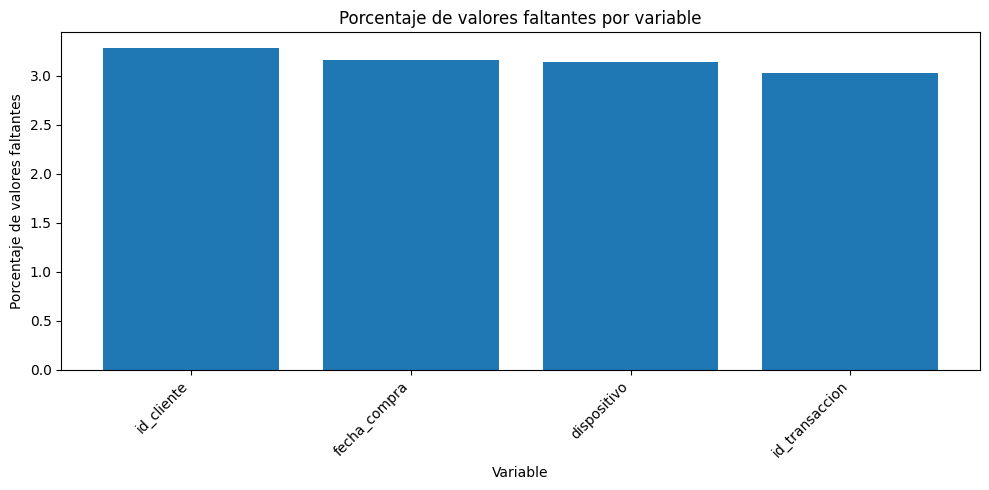

In [11]:
faltantes_grafica = auditoria_completitud[
    auditoria_completitud["Valores_faltantes"] > 0
]

plt.figure(figsize=(10, 5))

plt.bar(
    faltantes_grafica["Variable"],
    faltantes_grafica["Porcentaje_faltantes"]
)

plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de valores faltantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación de la completitud

El dataset presenta valores faltantes en las variables `id_transaccion`, `fecha_compra`, `id_cliente` y `dispositivo`.

Los porcentajes de ausencia se encuentran aproximadamente entre el 3 % y el 3,3 %. Aunque no representan una proporción elevada del dataset, estas variables cumplen funciones diferentes y no deben recibir el mismo tratamiento.

- `id_transaccion` funciona como identificador del registro.
- `fecha_compra` permite realizar análisis temporales.
- `id_cliente` permite relacionar transacciones pertenecientes a un mismo cliente.
- `dispositivo` es una variable categórica descriptiva.

Por esta razón, el tratamiento de los valores faltantes se decidirá individualmente y no mediante una eliminación general de todas las filas incompletas.

### 3.2 Unicidad y registros duplicados

La unicidad evalúa si cada registro representa una observación diferente.

En este dataset, la variable `id_transaccion` debería identificar de manera única cada compra. Por esta razón, se revisan dos tipos de duplicados:

1. Filas completamente duplicadas.
2. Identificadores de transacción repetidos.

No se eliminan registros todavía, debido a que primero se debe establecer si los identificadores repetidos corresponden a duplicados exactos o a transacciones con información diferente.

In [12]:
# Cantidad de filas completamente duplicadas
duplicados_completos = df.duplicated().sum()

# Identificadores repetidos, excluyendo valores faltantes
duplicados_id = df["id_transaccion"].dropna().duplicated().sum()

print(f"Filas completamente duplicadas: {duplicados_completos}")
print(f"ID de transacción repetidos: {duplicados_id}")

Filas completamente duplicadas: 62
ID de transacción repetidos: 78


In [13]:
filas_duplicadas = df[df.duplicated(keep=False)].sort_values(
    by="id_transaccion"
)

print(f"Total de registros involucrados en duplicados completos: {len(filas_duplicadas)}")

display(filas_duplicadas.head(20))

Total de registros involucrados en duplicados completos: 124


,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
7161,TXN-0000275,5/5/2022,"36,888.00",Deportes,151609,Tarjeta dÃ©bito,App mÃ³vil,Android,MedellÃ­n,1,5,No
8015,TXN-0000275,5/5/2022,"36,888.00",Deportes,151609,Tarjeta dÃ©bito,App mÃ³vil,Android,MedellÃ­n,1,5,No
1688,TXN-0000384,12/7/2022,"32,550.00",Alimentos,72991,Tarjeta dÃ©bito,App mÃ³vil,Android,Manizales,2,5,No
8023,TXN-0000384,12/7/2022,"32,550.00",Alimentos,72991,Tarjeta dÃ©bito,App mÃ³vil,Android,Manizales,2,5,No
8017,TXN-0000705,2/18/2024,"46,290.00",Alimentos,47733,Contraentrega,Sitio web,Android,Cartagena,4,5,No
1281,TXN-0000705,2/18/2024,"46,290.00",Alimentos,47733,Contraentrega,Sitio web,Android,Cartagena,4,5,No
8072,TXN-0000790,5/31/2022,"16,274.00",TecnologÃ­a,1637008,Tarjeta dÃ©bito,App mÃ³vil,iOS,Pereira,4,5,No
4591,TXN-0000790,5/31/2022,"16,274.00",TecnologÃ­a,1637008,Tarjeta dÃ©bito,App mÃ³vil,iOS,Pereira,4,5,No
8050,TXN-0000835,7/17/2024,NaN,Hogar,222188,PSE,App mÃ³vil,Android,Barranquilla,8,4,No
4618,TXN-0000835,7/17/2024,NaN,Hogar,222188,PSE,App mÃ³vil,Android,Barranquilla,8,4,No


In [14]:
ids_repetidos = df[
    df["id_transaccion"].notna()
    & df["id_transaccion"].duplicated(keep=False)
].sort_values(by="id_transaccion")

print(
    f"Registros asociados con identificadores repetidos: "
    f"{len(ids_repetidos)}"
)

display(ids_repetidos.head(30))

Registros asociados con identificadores repetidos: 156


,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
7161,TXN-0000275,5/5/2022,"36,888.00",Deportes,151609,Tarjeta dÃ©bito,App mÃ³vil,Android,MedellÃ­n,1,5,No
8015,TXN-0000275,5/5/2022,"36,888.00",Deportes,151609,Tarjeta dÃ©bito,App mÃ³vil,Android,MedellÃ­n,1,5,No
1688,TXN-0000384,12/7/2022,"32,550.00",Alimentos,72991,Tarjeta dÃ©bito,App mÃ³vil,Android,Manizales,2,5,No
8023,TXN-0000384,12/7/2022,"32,550.00",Alimentos,72991,Tarjeta dÃ©bito,App mÃ³vil,Android,Manizales,2,5,No
8005,TXN-0000546,10/3/2022,"30,609.00",Hogar,145453,Contraentrega,App mÃ³vil,Android,CÃšCUTA,4,5,No
647,TXN-0000546,10/3/2022,"30,609.00",Hogar,145453,Contraentrega,App mÃ³vil,Android,CÃºcuta,4,5,No
8017,TXN-0000705,2/18/2024,"46,290.00",Alimentos,47733,Contraentrega,Sitio web,Android,Cartagena,4,5,No
1281,TXN-0000705,2/18/2024,"46,290.00",Alimentos,47733,Contraentrega,Sitio web,Android,Cartagena,4,5,No
4591,TXN-0000790,5/31/2022,"16,274.00",TecnologÃ­a,1637008,Tarjeta dÃ©bito,App mÃ³vil,iOS,Pereira,4,5,No
8072,TXN-0000790,5/31/2022,"16,274.00",TecnologÃ­a,1637008,Tarjeta dÃ©bito,App mÃ³vil,iOS,Pereira,4,5,No


In [15]:
comparacion_ids = (
    ids_repetidos
    .groupby("id_transaccion")
    .agg(
        cantidad_registros=("id_transaccion", "size"),
        cantidad_fechas=("fecha_compra", "nunique"),
        cantidad_clientes=("id_cliente", "nunique"),
        cantidad_precios=("precio_cop", "nunique"),
        cantidad_productos=("categoria_producto", "nunique")
    )
    .reset_index()
)

display(comparacion_ids.head(20))

,id_transaccion,cantidad_registros,cantidad_fechas,cantidad_clientes,cantidad_precios,cantidad_productos
0,TXN-0000275,2,1,1,1,1
1,TXN-0000384,2,1,1,1,1
2,TXN-0000546,2,1,1,1,1
3,TXN-0000705,2,1,1,1,1
4,TXN-0000790,2,1,1,1,1
5,TXN-0000835,2,1,0,1,1
6,TXN-0000859,2,1,1,1,1
7,TXN-0000969,2,1,1,1,2
8,TXN-0001025,2,1,1,1,1
9,TXN-0001397,2,1,1,1,1


#### Interpretación de la unicidad

Se encontraron 62 filas completamente duplicadas y 78 repeticiones adicionales en la variable `id_transaccion`.

La presencia de identificadores repetidos puede afectar el cálculo de ventas, número de compras, devoluciones y comportamiento de los clientes.

Antes de eliminar estos registros, se comparan las demás variables para determinar si:

- Son copias exactas de una misma transacción.
- Corresponden a un mismo identificador con información diferente.
- Se produjo un error en la generación del identificador.

Las filas completamente idénticas podrán eliminarse conservando una sola copia. Los identificadores repetidos con información distinta requerirán una revisión adicional.

### 3.3 Consistencia de variables categóricas

La consistencia evalúa si una misma categoría está representada siempre de la misma manera.

En las variables categóricas pueden presentarse diferencias por:

- Uso de mayúsculas y minúsculas.
- Espacios al inicio o al final.
- Errores de codificación de caracteres.
- Variaciones en la escritura de una misma categoría.

Estas inconsistencias pueden generar categorías artificialmente separadas y alterar los resultados del análisis.

In [16]:
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()

print("Columnas categóricas:")
print(columnas_categoricas)

Columnas categóricas:
['id_transaccion', 'fecha_compra', 'categoria_producto', 'metodo_pago', 'canal', 'dispositivo', 'ciudad_envio', 'producto_devuelto']


In [17]:
resumen_categorias = pd.DataFrame({
    "Variable": columnas_categoricas,
    "Cantidad_categorias": [
        df[columna].nunique(dropna=True)
        for columna in columnas_categoricas
    ],
    "Valores_faltantes": [
        df[columna].isna().sum()
        for columna in columnas_categoricas
    ]
})

display(resumen_categorias)

,Variable,Cantidad_categorias,Valores_faltantes
0,id_transaccion,7757,245
1,fecha_compra,1096,255
2,categoria_producto,20,0
3,metodo_pago,5,0
4,canal,2,0
5,dispositivo,3,254
6,ciudad_envio,20,0
7,producto_devuelto,2,0


In [18]:
for columna in columnas_categoricas:
    print("=" * 70)
    print(f"VARIABLE: {columna}")
    print("=" * 70)

    frecuencias = (
        df[columna]
        .value_counts(dropna=False)
        .rename_axis("Categoría")
        .reset_index(name="Frecuencia")
    )

    display(frecuencias)

VARIABLE: id_transaccion


,Categoría,Frecuencia
0,NaN,245
1,TXN-0006652,2
2,TXN-0007097,2
3,TXN-0005240,2
4,TXN-0000275,2
...,...,...
7753,TXN-0007840,1
7754,TXN-0002561,1
7755,TXN-0005470,1
7756,TXN-0000127,1


VARIABLE: fecha_compra


,Categoría,Frecuencia
0,NaN,255
1,5/21/2022,18
2,12/8/2023,16
3,9/21/2022,16
4,2/16/2023,16
...,...,...
1092,5/18/2023,2
1093,5/11/2024,2
1094,1/19/2024,2
1095,9/21/2024,1


VARIABLE: categoria_producto


...

,Categoría,Frecuencia
0,Android,4302
1,iOS,1929
2,Desktop,1595
3,NaN,254


VARIABLE: ciudad_envio


,Categoría,Frecuencia
0,BogotÃ¡,2260
1,MedellÃ­n,1202
2,Cali,1037
3,Barranquilla,704
4,Bucaramanga,533
5,Cartagena,462
6,Pereira,457
7,Manizales,366
8,IbaguÃ©,329
9,CÃºcuta,316


VARIABLE: producto_devuelto


,Categoría,Frecuencia
0,No,7796
1,SÃ­,284


In [19]:
reporte_espacios = []

for columna in columnas_categoricas:

    serie_texto = df[columna].dropna().astype(str)

    cantidad_espacios = (
        serie_texto != serie_texto.str.strip()
    ).sum()

    reporte_espacios.append({
        "Variable": columna,
        "Registros_con_espacios_externos": cantidad_espacios
    })

reporte_espacios = pd.DataFrame(reporte_espacios)

display(reporte_espacios)

,Variable,Registros_con_espacios_externos
0,id_transaccion,0
1,fecha_compra,0
2,categoria_producto,0
3,metodo_pago,0
4,canal,0
5,dispositivo,0
6,ciudad_envio,0
7,producto_devuelto,0


In [20]:
def texto_comparable(valor):
    """
    Genera una versión auxiliar del texto para detectar categorías
    equivalentes. No modifica el dataset original.
    """
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().lower()

    valor = unicodedata.normalize("NFKD", valor)

    valor = "".join(
        caracter
        for caracter in valor
        if not unicodedata.combining(caracter)
    )

    return valor


for columna in columnas_categoricas:

    comparacion = pd.DataFrame({
        "Valor_original": df[columna],
        "Valor_comparable": df[columna].apply(texto_comparable)
    })

    comparacion = (
        comparacion
        .dropna()
        .drop_duplicates()
        .sort_values("Valor_comparable")
    )

    print("=" * 70)
    print(f"COMPARACIÓN DE CATEGORÍAS: {columna}")
    print("=" * 70)

    display(comparacion)

COMPARACIÓN DE CATEGORÍAS: id_transaccion


,Valor_original,Valor_comparable
1374,TXN-0000001,txn-0000001
6390,TXN-0000002,txn-0000002
5836,TXN-0000003,txn-0000003
4809,TXN-0000004,txn-0000004
3879,TXN-0000005,txn-0000005
...,...,...
506,TXN-0007996,txn-0007996
7357,TXN-0007997,txn-0007997
7651,TXN-0007998,txn-0007998
3404,TXN-0007999,txn-0007999


COMPARACIÓN DE CATEGORÍAS: fecha_compra


,Valor_original,Valor_comparable
2186,1/1/2022,1/1/2022
4122,1/1/2023,1/1/2023
707,1/1/2024,1/1/2024
736,1/10/2022,1/10/2022
3544,1/10/2023,1/10/2023
...,...,...
207,9/8/2023,9/8/2023
272,9/8/2024,9/8/2024
1714,9/9/2022,9/9/2022
812,9/9/2023,9/9/2023


COMPARACIÓN DE CATEGORÍAS: categoria_producto


...

,Valor_original,Valor_comparable
4,Android,android
1,Desktop,desktop
0,iOS,ios


COMPARACIÓN DE CATEGORÍAS: ciudad_envio


,Valor_original,Valor_comparable
40,Barranquilla,barranquilla
163,BARRANQUILLA,barranquilla
161,BOGOTÃ,bogota
3,BogotÃ¡,bogota¡
43,BUCARAMANGA,bucaramanga
113,Bucaramanga,bucaramanga
1,Cali,cali
25,CALI,cali
18,CÃºcuta,caocuta
7,Cartagena,cartagena


COMPARACIÓN DE CATEGORÍAS: producto_devuelto


,Valor_original,Valor_comparable
0,No,no
12,SÃ­,sa­


#### Interpretación de la consistencia

Se identificaron diferentes representaciones para categorías equivalentes.

Por ejemplo, algunas categorías aparecen en formato normal y también completamente en mayúsculas. Además, varias palabras presentan problemas de codificación, como `BogotÃ¡`, `TecnologÃ­a`, `App mÃ³vil` y `SÃ­`.

Estas diferencias no representan categorías reales distintas, sino inconsistencias de almacenamiento y escritura.

En la etapa de limpieza se aplicará el siguiente orden:

1. Corrección de caracteres dañados.
2. Eliminación de espacios innecesarios.
3. Homologación del uso de mayúsculas y minúsculas.
4. Validación de las categorías resultantes.

Este orden evita conservar errores de codificación dentro de las categorías normalizadas.

### 3.4 Validez de los datos

La validez determina si los valores cumplen las reglas esperadas según el significado de cada variable.

En este dataset se revisan principalmente:

- Fechas válidas.
- Precios mayores que cero.
- Tiempos de entrega positivos.
- Calificaciones dentro de la escala permitida.
- Valores válidos en la variable de devolución.
- Formato de los identificadores de transacción.

In [21]:
# Conversión temporal para evaluar la validez
fechas_convertidas = pd.to_datetime(
    df["fecha_compra"],
    errors="coerce"
)

fechas_faltantes_originales = df["fecha_compra"].isna().sum()
fechas_invalidas = (
    fechas_convertidas.isna().sum()
    - fechas_faltantes_originales
)

print(f"Fechas faltantes: {fechas_faltantes_originales}")
print(f"Fechas con formato inválido: {fechas_invalidas}")

print("\nFecha mínima:")
print(fechas_convertidas.min())

print("\nFecha máxima:")
print(fechas_convertidas.max())

Fechas faltantes: 255
Fechas con formato inválido: 0

Fecha mínima:
2022-01-01 00:00:00

Fecha máxima:
2024-12-31 00:00:00


In [22]:
resumen_precio = pd.DataFrame({
    "Indicador": [
        "Valor mínimo",
        "Valor máximo",
        "Valores iguales a cero",
        "Valores negativos",
        "Valores faltantes"
    ],
    "Resultado": [
        df["precio_cop"].min(),
        df["precio_cop"].max(),
        (df["precio_cop"] == 0).sum(),
        (df["precio_cop"] < 0).sum(),
        df["precio_cop"].isna().sum()
    ]
})

display(resumen_precio)

,Indicador,Resultado
0,Valor mínimo,5000
1,Valor máximo,1902012
2,Valores iguales a cero,0
3,Valores negativos,0
4,Valores faltantes,0


In [23]:
resumen_entrega = pd.DataFrame({
    "Indicador": [
        "Tiempo mínimo",
        "Tiempo máximo",
        "Valores iguales a cero",
        "Valores negativos",
        "Valores faltantes"
    ],
    "Resultado": [
        df["tiempo_entrega_dias"].min(),
        df["tiempo_entrega_dias"].max(),
        (df["tiempo_entrega_dias"] == 0).sum(),
        (df["tiempo_entrega_dias"] < 0).sum(),
        df["tiempo_entrega_dias"].isna().sum()
    ]
})

display(resumen_entrega)

,Indicador,Resultado
0,Tiempo mínimo,1
1,Tiempo máximo,14
2,Valores iguales a cero,0
3,Valores negativos,0
4,Valores faltantes,0


In [24]:
print("Calificaciones encontradas:")
print(sorted(df["calificacion_cliente_1a5"].dropna().unique()))

calificaciones_invalidas = df[
    ~df["calificacion_cliente_1a5"].between(1, 5)
]

print(
    f"Cantidad de calificaciones fuera del rango de 1 a 5: "
    f"{len(calificaciones_invalidas)}"
)

Calificaciones encontradas:
[np.int64(3), np.int64(4), np.int64(5)]
Cantidad de calificaciones fuera del rango de 1 a 5: 0


In [25]:
print("Valores presentes en producto_devuelto:")

display(
    df["producto_devuelto"]
    .value_counts(dropna=False)
    .rename_axis("Valor")
    .reset_index(name="Frecuencia")
)

Valores presentes en producto_devuelto:


,Valor,Frecuencia
0,No,7796
1,SÃ­,284


In [26]:
patron_transaccion = r"^TXN-\d{7}$"

id_invalidos = df[
    df["id_transaccion"].notna()
    & ~df["id_transaccion"].str.match(patron_transaccion, na=False)
]

print(f"Identificadores con formato inválido: {len(id_invalidos)}")

display(id_invalidos.head(20))

Identificadores con formato inválido: 0


,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto


In [27]:
resumen_cliente = pd.DataFrame({
    "Indicador": [
        "ID mínimo",
        "ID máximo",
        "ID iguales a cero",
        "ID negativos",
        "ID faltantes"
    ],
    "Resultado": [
        df["id_cliente"].min(),
        df["id_cliente"].max(),
        (df["id_cliente"] == 0).sum(),
        (df["id_cliente"] < 0).sum(),
        df["id_cliente"].isna().sum()
    ]
})

display(resumen_cliente)

,Indicador,Resultado
0,ID mínimo,"10,001.00"
1,ID máximo,"59,991.00"
2,ID iguales a cero,0.00
3,ID negativos,0.00
4,ID faltantes,265.00


In [28]:
reporte_validez = pd.DataFrame({
    "Regla evaluada": [
        "Precio mayor que cero",
        "Tiempo de entrega mayor que cero",
        "Calificación entre 1 y 5",
        "Formato válido del ID de transacción",
        "ID de cliente positivo"
    ],
    "Registros que incumplen": [
        (df["precio_cop"] <= 0).sum(),
        (df["tiempo_entrega_dias"] <= 0).sum(),
        (~df["calificacion_cliente_1a5"].between(1, 5)).sum(),
        len(id_invalidos),
        (df["id_cliente"].dropna() <= 0).sum()
    ]
})

display(reporte_validez)

,Regla evaluada,Registros que incumplen
0,Precio mayor que cero,0
1,Tiempo de entrega mayor que cero,0
2,Calificación entre 1 y 5,0
3,Formato válido del ID de transacción,0
4,ID de cliente positivo,0


#### Interpretación de la validez

Las variables numéricas presentan valores dentro de los rangos esperados:

- Los precios son mayores que cero.
- El tiempo de entrega se encuentra entre 1 y 14 días.
- Las calificaciones están dentro de la escala de 1 a 5.
- No se identificaron valores negativos en las variables analizadas.

La principal dificultad de validez se concentra en los valores faltantes y en las inconsistencias de texto.

La variable `fecha_compra` utiliza un formato mes/día/año. Por esta razón, en la limpieza se realizará una conversión explícita a tipo fecha y posteriormente se presentará en un formato estándar.

### 3.5 Trazabilidad

La trazabilidad permite registrar el origen de los datos, las transformaciones realizadas y los efectos de cada decisión sobre el dataset.

Para conservar la trazabilidad:

- Se mantiene una copia del dataset original.
- Se trabaja sobre una copia independiente.
- Se registra la dimensión inicial.
- Se crea una bitácora para documentar cada transformación.
- Se conservará el número de registros afectados por cada cambio.

In [29]:
trazabilidad_inicial = {
    "archivo_origen": nombre_archivo,
    "filas_originales": df_original.shape[0],
    "columnas_originales": df_original.shape[1],
    "duplicados_completos": df_original.duplicated().sum(),
    "total_valores_faltantes": int(
        df_original.isna().sum().sum()
    )
}

trazabilidad_inicial

{'archivo_origen': '03_comercio_electronico_transacciones(in).csv',
 'filas_originales': 8080,
 'columnas_originales': 12,
 'duplicados_completos': np.int64(62),
 'total_valores_faltantes': 1019}

In [30]:
bitacora_cambios = []

def registrar_cambio(
    paso,
    variable,
    accion,
    registros_afectados,
    justificacion
):
    """
    Agrega una transformación a la bitácora del pipeline.
    """

    bitacora_cambios.append({
        "Paso": paso,
        "Variable": variable,
        "Acción": accion,
        "Registros_afectados": registros_afectados,
        "Justificación": justificacion
    })

In [31]:
bitacora_df = pd.DataFrame(bitacora_cambios)

display(bitacora_df)

""


In [32]:
reporte_calidad_inicial = {
    "Cantidad_filas": len(df),
    "Cantidad_columnas": df.shape[1],
    "Valores_faltantes": int(df.isna().sum().sum()),
    "Filas_duplicadas": int(df.duplicated().sum()),
    "ID_transaccion_repetidos": int(
        df["id_transaccion"].dropna().duplicated().sum()
    ),
    "Categorias_con_inconsistencias": [
        "categoria_producto",
        "ciudad_envio"
    ],
    "Variables_con_problemas_codificacion": [
        "categoria_producto",
        "metodo_pago",
        "canal",
        "ciudad_envio",
        "producto_devuelto"
    ]
}

reporte_calidad_inicial

{'Cantidad_filas': 8080,
 'Cantidad_columnas': 12,
 'Valores_faltantes': 1019,
 'Filas_duplicadas': 62,
 'ID_transaccion_repetidos': 78,
 'Categorias_con_inconsistencias': ['categoria_producto', 'ciudad_envio'],
 'Variables_con_problemas_codificacion': ['categoria_producto',
  'metodo_pago',
  'canal',
  'ciudad_envio',
  'producto_devuelto']}

### Conclusión de la auditoría inicial

La auditoría permitió identificar los principales problemas de calidad antes de realizar cualquier transformación:

1. Valores faltantes en cuatro variables.
2. Filas completamente duplicadas.
3. Identificadores de transacción repetidos.
4. Categorías duplicadas por diferencias entre mayúsculas y minúsculas.
5. Caracteres dañados por problemas de codificación.
6. Variables almacenadas con tipos de datos que deben ajustarse.

Las variables numéricas presentan rangos válidos y no muestran valores negativos o iguales a cero en campos donde no serían aceptables.

A partir de estos hallazgos, el siguiente paso será construir el pipeline de limpieza, comenzando por la corrección de caracteres y la homologación de las variables categóricas.

## 4. Limpieza y normalización de variables categóricas

Después de identificar inconsistencias en las variables de texto, se procede a corregir problemas de codificación, eliminar espacios innecesarios y homologar categorías.

La transformación se realiza de forma controlada y se registra en la bitácora para conservar la trazabilidad del pipeline.

In [33]:
def corregir_codificacion(texto):
    """
    Corrige algunos problemas frecuentes de codificación UTF-8/Latin-1.
    """
    if pd.isna(texto):
        return texto

    texto = str(texto)

    try:
        texto_corregido = texto.encode("latin1").decode("utf8")
        return texto_corregido
    except:
        return texto

In [34]:
for columna in columnas_categoricas:

    antes = df[columna].copy()

    df[columna] = df[columna].apply(corregir_codificacion)

    afectados = (
        antes.fillna("NULO") != df[columna].fillna("NULO")
    ).sum()

    if afectados > 0:
        registrar_cambio(
            paso="4.1",
            variable=columna,
            accion="Corrección de codificación de caracteres",
            registros_afectados=int(afectados),
            justificacion="Se corrigieron caracteres dañados para evitar categorías artificialmente diferentes."
        )

In [35]:
for columna in columnas_categoricas:

    print("=" * 60)
    print(columna)
    print("=" * 60)

    print(df[columna].value_counts(dropna=False))
    print()

id_transaccion
id_transaccion
NaN            245
TXN-0006652      2
TXN-0007097      2
TXN-0005240      2
TXN-0000275      2
              ... 
TXN-0007840      1
TXN-0002561      1
TXN-0005470      1
TXN-0000127      1
TXN-0004197      1
Name: count, Length: 7758, dtype: int64

fecha_compra
fecha_compra
NaN          255
5/21/2022     18
12/8/2023     16
9/21/2022     16
2/16/2023     16
            ... 
5/18/2023      2
5/11/2024      2
1/19/2024      2
9/21/2024      1
1/4/2023       1
Name: count, Length: 1097, dtype: int64

categoria_producto
categoria_producto
Moda            1330
Electrónica     1207
Hogar            931
Belleza          852
Deportes         705
Alimentos        703
Tecnología       536
Juguetes         533
Libros           459
Mascotas         390
MODA              80
ELECTRÃ“NICA      76
HOGAR             57
DEPORTES          50
BELLEZA           50
ALIMENTOS         32
JUGUETES          30
TECNOLOGÍA        21
MASCOTAS          20
LIBROS            18
Name: co

### 4.2 Eliminación de espacios

Los espacios al inicio o al final de los textos pueden generar categorías diferentes aunque representen el mismo valor.

Por esta razón, se eliminan únicamente los espacios externos, conservando los espacios internos necesarios.

In [36]:
for columna in columnas_categoricas:

    antes = df[columna].copy()

    df[columna] = df[columna].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

    afectados = (
        antes.fillna("NULO") != df[columna].fillna("NULO")
    ).sum()

    if afectados > 0:
        registrar_cambio(
            paso="4.2",
            variable=columna,
            accion="Eliminación de espacios externos",
            registros_afectados=int(afectados),
            justificacion="Se eliminaron espacios innecesarios que podían generar categorías duplicadas."
        )

### 4.3 Homologación de categorías

Se identificaron categorías equivalentes escritas de diferentes formas, principalmente por diferencias entre mayúsculas y minúsculas.

Para evitar que una misma categoría sea interpretada como grupos diferentes, se homologa su representación manteniendo una escritura legible.

In [37]:
for columna in columnas_categoricas:

    print(f"\n{columna}")
    print(sorted(
        df[columna]
        .dropna()
        .astype(str)
        .unique()
    ))


id_transaccion
['TXN-0000001', 'TXN-0000002', 'TXN-0000003', 'TXN-0000004', 'TXN-0000005', 'TXN-0000006', 'TXN-0000007', 'TXN-0000008', 'TXN-0000009', 'TXN-0000010', 'TXN-0000011', 'TXN-0000012', 'TXN-0000013', 'TXN-0000014', 'TXN-0000015', 'TXN-0000016', 'TXN-0000017', 'TXN-0000018', 'TXN-0000019', 'TXN-0000020', 'TXN-0000021', 'TXN-0000022', 'TXN-0000023', 'TXN-0000024', 'TXN-0000025', 'TXN-0000026', 'TXN-0000027', 'TXN-0000028', 'TXN-0000029', 'TXN-0000030', 'TXN-0000031', 'TXN-0000032', 'TXN-0000033', 'TXN-0000034', 'TXN-0000035', 'TXN-0000036', 'TXN-0000037', 'TXN-0000038', 'TXN-0000039', 'TXN-0000040', 'TXN-0000041', 'TXN-0000042', 'TXN-0000043', 'TXN-0000044', 'TXN-0000045', 'TXN-0000046', 'TXN-0000047', 'TXN-0000048', 'TXN-0000049', 'TXN-0000050', 'TXN-0000051', 'TXN-0000052', 'TXN-0000053', 'TXN-0000054', 'TXN-0000055', 'TXN-0000056', 'TXN-0000057', 'TXN-0000058', 'TXN-0000059', 'TXN-0000060', 'TXN-0000061', 'TXN-0000062', 'TXN-0000063', 'TXN-0000064', 'TXN-0000065', 'TXN-000

In [38]:
def normalizar_categoria(valor):

    if pd.isna(valor):
        return valor

    valor = str(valor).strip()

    return valor.capitalize()

In [39]:
for columna in columnas_categoricas:

    antes = df[columna].copy()

    df[columna] = df[columna].apply(normalizar_categoria)

    afectados = (
        antes.fillna("NULO") != df[columna].fillna("NULO")
    ).sum()

    if afectados > 0:
        registrar_cambio(
            paso="4.3",
            variable=columna,
            accion="Homologación de categorías",
            registros_afectados=int(afectados),
            justificacion="Se estandarizó la escritura de categorías equivalentes."
        )

In [41]:
comparacion_categorias = []

for columna in columnas_categoricas:

    categorias_originales = df_original[columna].nunique(dropna=True)
    categorias_limpias = df[columna].nunique(dropna=True)

    comparacion_categorias.append({
        "Variable": columna,
        "Categorías_originales": categorias_originales,
        "Categorías_limpias": categorias_limpias,
        "Reducción": categorias_originales - categorias_limpias
    })

comparacion_categorias = pd.DataFrame(comparacion_categorias)

display(comparacion_categorias)

,Variable,Categorías_originales,Categorías_limpias,Reducción
0,id_transaccion,7757,7757,0
1,fecha_compra,1096,1096,0
2,categoria_producto,20,11,9
3,metodo_pago,5,5,0
4,canal,2,2,0
5,dispositivo,3,3,0
6,ciudad_envio,20,12,8
7,producto_devuelto,2,2,0


### 4.4 Segunda verificación de duplicados

Después de normalizar las variables categóricas, se realiza una segunda revisión de duplicados.

Esto es necesario porque dos registros que inicialmente parecían diferentes pueden convertirse en registros idénticos después de corregir mayúsculas, caracteres y espacios.

In [42]:
duplicados_antes = df_original.duplicated().sum()
duplicados_despues_homologacion = df.duplicated().sum()

print(f"Duplicados en el dataset original: {duplicados_antes}")
print(
    f"Duplicados después de homologar categorías: "
    f"{duplicados_despues_homologacion}"
)

Duplicados en el dataset original: 62
Duplicados después de homologar categorías: 74


In [43]:
duplicados_post_limpieza = df[
    df.duplicated(keep=False)
].sort_values("id_transaccion")

display(duplicados_post_limpieza.head(30))

,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
7161,Txn-0000275,5/5/2022,"36,888.00",Deportes,151609,Tarjeta débito,App móvil,Android,Medellín,1,5,No
8015,Txn-0000275,5/5/2022,"36,888.00",Deportes,151609,Tarjeta débito,App móvil,Android,Medellín,1,5,No
8023,Txn-0000384,12/7/2022,"32,550.00",Alimentos,72991,Tarjeta débito,App móvil,Android,Manizales,2,5,No
1688,Txn-0000384,12/7/2022,"32,550.00",Alimentos,72991,Tarjeta débito,App móvil,Android,Manizales,2,5,No
8017,Txn-0000705,2/18/2024,"46,290.00",Alimentos,47733,Contraentrega,Sitio web,Android,Cartagena,4,5,No
1281,Txn-0000705,2/18/2024,"46,290.00",Alimentos,47733,Contraentrega,Sitio web,Android,Cartagena,4,5,No
4591,Txn-0000790,5/31/2022,"16,274.00",Tecnología,1637008,Tarjeta débito,App móvil,Ios,Pereira,4,5,No
8072,Txn-0000790,5/31/2022,"16,274.00",Tecnología,1637008,Tarjeta débito,App móvil,Ios,Pereira,4,5,No
8050,Txn-0000835,7/17/2024,NaN,Hogar,222188,Pse,App móvil,Android,Barranquilla,8,4,No
4618,Txn-0000835,7/17/2024,NaN,Hogar,222188,Pse,App móvil,Android,Barranquilla,8,4,No


## 5. Tratamiento de registros duplicados

Los registros completamente duplicados pueden producir sobreestimaciones en indicadores como número de compras, ingresos y frecuencia de transacciones.

Se elimina únicamente la repetición exacta, conservando la primera aparición del registro.

Los identificadores de transacción repetidos con información diferente no se eliminan automáticamente, ya que podrían representar problemas distintos que requieren una revisión específica.

In [44]:
filas_antes = len(df)

df = df.drop_duplicates().copy()

filas_despues = len(df)

duplicados_eliminados = filas_antes - filas_despues

print(f"Filas antes: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Duplicados eliminados: {duplicados_eliminados}")

Filas antes: 8080
Filas después: 8006
Duplicados eliminados: 74


In [45]:
registrar_cambio(
    paso="5",
    variable="Dataset completo",
    accion="Eliminación de registros completamente duplicados",
    registros_afectados=int(duplicados_eliminados),
    justificacion="Los registros idénticos pueden sobreestimar métricas de compras, ingresos y comportamiento."
)

## 6. Tratamiento de valores faltantes

Los valores faltantes se analizan según el significado de cada variable.

No se aplica una única estrategia para todo el dataset, ya que eliminar o imputar datos sin considerar su función puede introducir sesgos o información artificial.

Las variables con faltantes son:

- `id_transaccion`
- `fecha_compra`
- `id_cliente`
- `dispositivo`

### 6.1 Valores faltantes en `id_transaccion`

El identificador de transacción es una variable administrativa utilizada para distinguir registros.

Eliminar una fila únicamente porque este identificador está ausente implicaría perder información disponible sobre la compra.

Por esta razón, se generan identificadores técnicos para los registros sin `id_transaccion`. Estos identificadores se diferencian claramente de los originales para mantener la trazabilidad y evitar confundirlos con identificadores reales de la fuente.

In [46]:
faltantes_id_transaccion = df["id_transaccion"].isna()

cantidad_faltantes_id = faltantes_id_transaccion.sum()

contador = 1

for indice in df[faltantes_id_transaccion].index:

    df.loc[indice, "id_transaccion"] = (
        f"TXN-IMPUTADO-{contador:04d}"
    )

    contador += 1

print(
    f"Identificadores técnicos creados: "
    f"{cantidad_faltantes_id}"
)

Identificadores técnicos creados: 243


In [47]:
registrar_cambio(
    paso="6.1",
    variable="id_transaccion",
    accion="Creación de identificadores técnicos para valores faltantes",
    registros_afectados=int(cantidad_faltantes_id),
    justificacion="Se conserva la información de la transacción sin inventar un identificador original."
)

### 6.2 Valores faltantes en `id_cliente`

El identificador del cliente representa una entidad específica, por lo que no resulta metodológicamente apropiado imputarlo con la media, mediana o moda.

Asignar un cliente arbitrariamente podría generar relaciones inexistentes y alterar análisis posteriores de comportamiento.

Los registros se conservan y los clientes faltantes se identifican mediante un código técnico de cliente desconocido.

In [48]:
print(df["id_cliente"].dtype)

float64


In [49]:
faltantes_cliente = df["id_cliente"].isna().sum()

df["id_cliente"] = df["id_cliente"].astype("Int64")

In [50]:
df["id_cliente"] = df["id_cliente"].fillna(-1)

print(
    f"Clientes faltantes identificados como -1: "
    f"{faltantes_cliente}"
)

Clientes faltantes identificados como -1: 264


In [51]:
registrar_cambio(
    paso="6.2",
    variable="id_cliente",
    accion="Asignación de código técnico -1 para cliente desconocido",
    registros_afectados=int(faltantes_cliente),
    justificacion="Se evita atribuir artificialmente una transacción a un cliente existente."
)

### 6.3 Valores faltantes en `dispositivo`

En la variable `dispositivo`, la ausencia de información no impide conservar la transacción.

En lugar de utilizar la moda, lo cual aumentaría artificialmente la frecuencia de la categoría dominante, los valores faltantes se representan mediante una categoría explícita denominada `Desconocido`.

In [52]:
faltantes_dispositivo = df["dispositivo"].isna().sum()

df["dispositivo"] = df["dispositivo"].fillna(
    "Desconocido"
)

print(
    f"Valores reemplazados por 'Desconocido': "
    f"{faltantes_dispositivo}"
)

Valores reemplazados por 'Desconocido': 252


In [53]:
registrar_cambio(
    paso="6.3",
    variable="dispositivo",
    accion="Creación de categoría Desconocido",
    registros_afectados=int(faltantes_dispositivo),
    justificacion="Se conserva el registro sin alterar artificialmente la distribución de las categorías existentes."
)

### 6.4 Valores faltantes en `fecha_compra`

La fecha de compra es una variable temporal y su imputación mediante media, mediana o moda podría introducir transacciones en periodos que no corresponden a la realidad.

Por esta razón, los valores faltantes se mantienen como `NaT` después de convertir la variable a tipo fecha.

Estos registros podrán utilizarse en análisis generales, pero deberán excluirse específicamente de análisis temporales que requieran conocer la fecha de la transacción.

In [54]:
df["fecha_compra"] = pd.to_datetime(
    df["fecha_compra"],
    errors="coerce"
)

faltantes_fecha = df["fecha_compra"].isna().sum()

print(
    f"Registros sin fecha después de la conversión: "
    f"{faltantes_fecha}"
)

Registros sin fecha después de la conversión: 251


In [55]:
registrar_cambio(
    paso="6.4",
    variable="fecha_compra",
    accion="Conversión a datetime y conservación de valores faltantes",
    registros_afectados=int(faltantes_fecha),
    justificacion="No se imputan fechas artificiales para evitar distorsionar los análisis temporales."
)

In [56]:
faltantes_despues = pd.DataFrame({
    "Variable": df.columns,
    "Valores_faltantes": df.isna().sum().values,
    "Porcentaje": (
        df.isna().mean().values * 100
    ).round(2)
})

display(
    faltantes_despues[
        faltantes_despues["Valores_faltantes"] > 0
    ]
)

,Variable,Valores_faltantes,Porcentaje
1,fecha_compra,251,3.14


In [57]:
bitacora_df = pd.DataFrame(bitacora_cambios)

display(bitacora_df)

,Paso,Variable,Acción,Registros_afectados,Justificación
0,4.1,categoria_producto,Corrección de codificación de caracteres,1764,Se corrigieron caracteres dañados para evitar ...
1,4.1,metodo_pago,Corrección de codificación de caracteres,4445,Se corrigieron caracteres dañados para evitar ...
2,4.1,canal,Corrección de codificación de caracteres,5051,Se corrigieron caracteres dañados para evitar ...
3,4.1,ciudad_envio,Corrección de codificación de caracteres,4277,Se corrigieron caracteres dañados para evitar ...
4,4.1,producto_devuelto,Corrección de codificación de caracteres,284,Se corrigieron caracteres dañados para evitar ...
5,4.3,id_transaccion,Homologación de categorías,7835,Se estandarizó la escritura de categorías equi...
6,4.3,categoria_producto,Homologación de categorías,434,Se estandarizó la escritura de categorías equi...
7,4.3,metodo_pago,Homologación de categorías,1606,Se estandarizó la escritura de categorías equi...
8,4.3,dispositivo,Homologación de categorías,1929,Se estandarizó la escritura de categorías equi...
9,4.3,ciudad_envio,Homologación de categorías,414,Se estandarizó la escritura de categorías equi...


In [58]:
bitacora_df.to_csv(
    "bitacora_limpieza.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Bitácora guardada correctamente.")

Bitácora guardada correctamente.


## 7. Ajuste de la homologación categórica

Durante la normalización inicial se identificó que no todas las columnas almacenadas como texto deben recibir el mismo tratamiento.

Variables como `id_transaccion` corresponden a identificadores y deben conservar su estructura. De igual forma, algunas categorías contienen siglas o nombres propios, como `PSE` e `iOS`.

Por esta razón, la normalización se restringe únicamente a las variables categóricas descriptivas y se definen explícitamente sus valores estandarizados.

In [62]:
columnas_categoricas_analisis = [
    "categoria_producto",
    "metodo_pago",
    "canal",
    "dispositivo",
    "ciudad_envio",
    "producto_devuelto"
]

print(columnas_categoricas_analisis)

['categoria_producto', 'metodo_pago', 'canal', 'dispositivo', 'ciudad_envio', 'producto_devuelto']


In [63]:
df["id_transaccion"] = (
    df["id_transaccion"]
    .astype("string")
    .str.replace(r"^Txn-", "TXN-", regex=True)
)

In [64]:
df["id_transaccion"] = (
    df["id_transaccion"]
    .str.replace(
        r"^TXN-imputado-",
        "TXN-IMPUTADO-",
        regex=True
    )
)

In [65]:
display(df["id_transaccion"].head(15))

,id_transaccion
0,TXN-0005239
1,TXN-0000262
2,TXN-IMPUTADO-0001
3,TXN-0005784
4,TXN-0001234
5,TXN-0006449
6,TXN-0006413
7,TXN-0000921
8,TXN-0000159
9,TXN-0007744


In [66]:
mapas_categorias = {

    "categoria_producto": {
        "Hogar": "Hogar",
        "HOGAR": "Hogar",
        "Alimentos": "Alimentos",
        "ALIMENTOS": "Alimentos",
        "Tecnología": "Tecnología",
        "TECNOLOGÍA": "Tecnología",
        "Belleza": "Belleza",
        "BELLEZA": "Belleza",
        "Libros": "Libros",
        "LIBROS": "Libros",
        "Electrónica": "Electrónica",
        "ELECTRÓNICA": "Electrónica",
        "Deportes": "Deportes",
        "DEPORTES": "Deportes",
        "Moda": "Moda",
        "MODA": "Moda",
        "Juguetes": "Juguetes",
        "JUGUETES": "Juguetes",
        "Mascotas": "Mascotas",
        "MASCOTAS": "Mascotas"
    },

    "ciudad_envio": {
        "Bogotá": "Bogotá",
        "BOGOTÁ": "Bogotá",
        "Medellín": "Medellín",
        "MEDELLÍN": "Medellín",
        "Cali": "Cali",
        "CALI": "Cali",
        "Barranquilla": "Barranquilla",
        "BARRANQUILLA": "Barranquilla",
        "Bucaramanga": "Bucaramanga",
        "BUCARAMANGA": "Bucaramanga",
        "Cartagena": "Cartagena",
        "CARTAGENA": "Cartagena",
        "Pereira": "Pereira",
        "PEREIRA": "Pereira",
        "Manizales": "Manizales",
        "MANIZALES": "Manizales",
        "Ibagué": "Ibagué",
        "IBAGUÉ": "Ibagué",
        "Cúcuta": "Cúcuta",
        "CÚCUTA": "Cúcuta"
    }
}

In [67]:
for columna, mapa in mapas_categorias.items():
    df[columna] = df[columna].replace(mapa)

In [68]:
df["metodo_pago"] = df["metodo_pago"].replace({
    "Pse": "PSE",
    "Tarjeta crédito": "Tarjeta crédito",
    "Tarjeta débito": "Tarjeta débito",
    "Billetera digital": "Billetera digital",
    "Contraentrega": "Contraentrega"
})

df["dispositivo"] = df["dispositivo"].replace({
    "Ios": "iOS",
    "IOS": "iOS",
    "Android": "Android",
    "Desktop": "Desktop",
    "Desconocido": "Desconocido"
})

df["canal"] = df["canal"].replace({
    "Sitio web": "Sitio web",
    "App móvil": "App móvil"
})

df["producto_devuelto"] = df["producto_devuelto"].replace({
    "Sí": "Sí",
    "No": "No"
})

In [69]:
for columna in columnas_categoricas_analisis:

    print(f"\n--- {columna} ---")

    print(
        df[columna]
        .value_counts(dropna=False)
    )


--- categoria_producto ---
categoria_producto
Moda            1392
Electrónica     1199
Hogar            982
Belleza          890
Deportes         748
Alimentos        726
Juguetes         556
Tecnología       554
Libros           476
Mascotas         407
Electrã“nica      76
Name: count, dtype: int64

--- metodo_pago ---
metodo_pago
Tarjeta crédito      2811
PSE                  1594
Tarjeta débito       1593
Contraentrega        1193
Billetera digital     815
Name: count, dtype: int64

--- canal ---
canal
App móvil    5001
Sitio web    3005
Name: count, dtype: int64

--- dispositivo ---
dispositivo
Android        4264
iOS            1906
Desktop        1584
Desconocido     252
Name: count, dtype: int64

--- ciudad_envio ---
ciudad_envio
Bogotá          2347
Medellín        1258
Cali            1074
Barranquilla     736
Bucaramanga      559
Pereira          486
Cartagena        479
Manizales        385
Ibagué           325
Cúcuta           312
Ibaguã‰           24
Cãšcuta           2

In [70]:
df["ciudad_envio"] = df["ciudad_envio"].replace({
    "Ibaguã‰": "Ibagué",
    "Cãšcuta": "Cúcuta"
})

In [71]:
print(df["ciudad_envio"].value_counts())

ciudad_envio
Bogotá          2347
Medellín        1258
Cali            1074
Barranquilla     736
Bucaramanga      559
Pereira          486
Cartagena        479
Manizales        385
Ibagué           349
Cúcuta           333
Name: count, dtype: int64


In [72]:
for columna in columnas_categoricas_analisis:
    print(f"\n--- {columna} ---")

    valores_raros = df[
        df[columna]
        .astype(str)
        .str.contains("Ã|Â|�", regex=True, na=False)
    ][columna].value_counts()

    if len(valores_raros) > 0:
        print(valores_raros)
    else:
        print("Sin problemas de codificación detectados.")


--- categoria_producto ---
Sin problemas de codificación detectados.

--- metodo_pago ---
Sin problemas de codificación detectados.

--- canal ---
Sin problemas de codificación detectados.

--- dispositivo ---
Sin problemas de codificación detectados.

--- ciudad_envio ---
Sin problemas de codificación detectados.

--- producto_devuelto ---
Sin problemas de codificación detectados.


In [73]:
registrar_cambio(
    paso="7.1",
    variable="ciudad_envio",
    accion="Corrección manual de categorías con codificación residual",
    registros_afectados=45,
    justificacion="Se corrigieron las categorías Ibagué y Cúcuta que conservaron caracteres dañados después de la normalización inicial."
)

In [74]:
for columna in columnas_categoricas_analisis:

    print(f"\n--- {columna} ---")

    print(
        df[columna]
        .value_counts(dropna=False)
    )


--- categoria_producto ---
categoria_producto
Moda            1392
Electrónica     1199
Hogar            982
Belleza          890
Deportes         748
Alimentos        726
Juguetes         556
Tecnología       554
Libros           476
Mascotas         407
Electrã“nica      76
Name: count, dtype: int64

--- metodo_pago ---
metodo_pago
Tarjeta crédito      2811
PSE                  1594
Tarjeta débito       1593
Contraentrega        1193
Billetera digital     815
Name: count, dtype: int64

--- canal ---
canal
App móvil    5001
Sitio web    3005
Name: count, dtype: int64

--- dispositivo ---
dispositivo
Android        4264
iOS            1906
Desktop        1584
Desconocido     252
Name: count, dtype: int64

--- ciudad_envio ---
ciudad_envio
Bogotá          2347
Medellín        1258
Cali            1074
Barranquilla     736
Bucaramanga      559
Pereira          486
Cartagena        479
Manizales        385
Ibagué           349
Cúcuta           333
Name: count, dtype: int64

--- producto_

## 8. Conversión de tipos de datos

Después de la limpieza se revisan nuevamente los tipos de las variables.

El objetivo es que cada columna utilice un tipo coherente con su significado:

- Los identificadores se conservan como variables de identificación.
- La fecha de compra se almacena como fecha.
- Las cantidades y escalas discretas se mantienen como enteros.
- El precio se conserva como variable numérica.
- Las variables descriptivas se mantienen como categóricas.

In [75]:
print("TIPOS ACTUALES")
print(df.dtypes)

TIPOS ACTUALES
id_transaccion              string[python]
fecha_compra                datetime64[ns]
id_cliente                           Int64
categoria_producto                  object
precio_cop                           int64
metodo_pago                         object
canal                               object
dispositivo                         object
ciudad_envio                        object
tiempo_entrega_dias                  int64
calificacion_cliente_1a5             int64
producto_devuelto                   object
dtype: object


In [76]:
# Identificador de transacción
df["id_transaccion"] = df["id_transaccion"].astype("string")

# Fecha
df["fecha_compra"] = pd.to_datetime(
    df["fecha_compra"],
    errors="coerce"
)

# Identificador de cliente
df["id_cliente"] = df["id_cliente"].astype("Int64")

# Precio
df["precio_cop"] = pd.to_numeric(
    df["precio_cop"],
    errors="coerce"
)

# Tiempo de entrega
df["tiempo_entrega_dias"] = pd.to_numeric(
    df["tiempo_entrega_dias"],
    errors="coerce"
).astype("Int64")

# Calificación
df["calificacion_cliente_1a5"] = pd.to_numeric(
    df["calificacion_cliente_1a5"],
    errors="coerce"
).astype("Int64")

In [77]:
columnas_categoricas_analisis = [
    "categoria_producto",
    "metodo_pago",
    "canal",
    "dispositivo",
    "ciudad_envio",
    "producto_devuelto"
]

for columna in columnas_categoricas_analisis:
    df[columna] = df[columna].astype("category")

In [78]:
resumen_tipos_final = pd.DataFrame({
    "Variable": df.columns,
    "Tipo_dato": df.dtypes.astype(str).values
})

display(resumen_tipos_final)

,Variable,Tipo_dato
0,id_transaccion,string
1,fecha_compra,datetime64[ns]
2,id_cliente,Int64
3,categoria_producto,category
4,precio_cop,int64
5,metodo_pago,category
6,canal,category
7,dispositivo,category
8,ciudad_envio,category
9,tiempo_entrega_dias,Int64


In [79]:
registrar_cambio(
    paso="8",
    variable="Varias variables",
    accion="Conversión y ajuste de tipos de datos",
    registros_afectados=len(df),
    justificacion="Se asignaron tipos coherentes con el significado y uso de cada variable."
)

## 9. Revisión de valores atípicos

Se analizaron posibles valores atípicos en las variables numéricas.

La detección de un valor atípico no implica necesariamente que se trate de un error. En un dataset de comercio electrónico pueden existir productos con precios considerablemente superiores al promedio.

Por esta razón, los valores identificados se analizan antes de decidir si deben modificarse o eliminarse.

In [80]:
variables_numericas = [
    "precio_cop",
    "tiempo_entrega_dias",
    "calificacion_cliente_1a5"
]

display(
    df[variables_numericas]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
precio_cop,"8,006.00","248,822.11","307,025.04","5,000.00","68,523.50","120,266.50","236,334.25","1,902,012.00"
tiempo_entrega_dias,"8,006.00",4.26,1.93,1.00,3.00,4.00,6.00,14.00
calificacion_cliente_1a5,"8,006.00",4.95,0.29,3.00,5.00,5.00,5.00,5.00


In [81]:
Q1 = df["precio_cop"].quantile(0.25)
Q3 = df["precio_cop"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_precio = df[
    (df["precio_cop"] < limite_inferior) |
    (df["precio_cop"] > limite_superior)
]

print(f"Q1: ${Q1:,.0f}")
print(f"Q3: ${Q3:,.0f}")
print(f"IQR: ${IQR:,.0f}")
print(f"Límite inferior: ${limite_inferior:,.0f}")
print(f"Límite superior: ${limite_superior:,.0f}")

print(
    f"\nCantidad de posibles valores atípicos: "
    f"{len(outliers_precio)}"
)

Q1: $68,524
Q3: $236,334
IQR: $167,811
Límite inferior: $-183,193
Límite superior: $488,050

Cantidad de posibles valores atípicos: 1395


In [82]:
display(
    outliers_precio[
        [
            "categoria_producto",
            "precio_cop",
            "ciudad_envio",
            "canal"
        ]
    ]
    .sort_values(
        by="precio_cop",
        ascending=False
    )
    .head(20)
)

,categoria_producto,precio_cop,ciudad_envio,canal
2013,Tecnología,1902012,Bogotá,App móvil
4135,Tecnología,1885662,Bogotá,App móvil
2768,Tecnología,1884097,Pereira,Sitio web
3850,Tecnología,1866461,Bogotá,Sitio web
3810,Tecnología,1839605,Barranquilla,App móvil
600,Tecnología,1799530,Manizales,App móvil
3970,Tecnología,1774042,Bogotá,App móvil
3786,Tecnología,1749580,Medellín,Sitio web
5700,Tecnología,1713095,Bogotá,App móvil
6701,Tecnología,1713059,Bucaramanga,App móvil


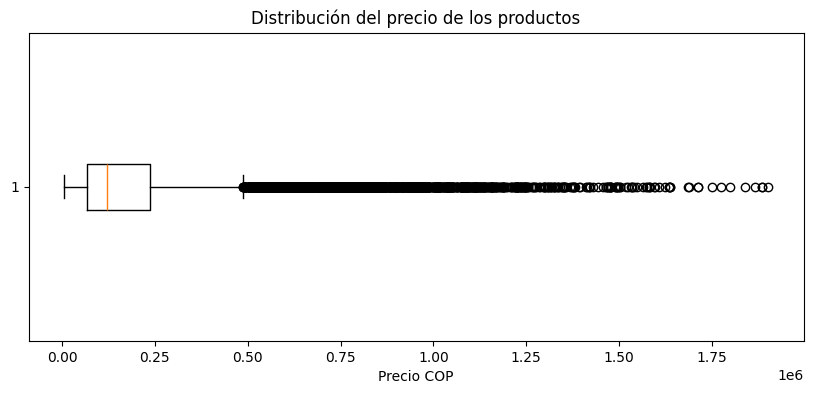

In [83]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df["precio_cop"].dropna(),
    vert=False
)

plt.title("Distribución del precio de los productos")
plt.xlabel("Precio COP")
plt.show()

### Interpretación

El método del rango intercuartílico identifica diferentes precios como posibles valores atípicos.

Sin embargo, no se encontraron precios negativos, iguales a cero o evidentemente imposibles. Debido a que el dataset contiene diferentes categorías de productos, los precios elevados pueden corresponder a artículos legítimamente más costosos.

Eliminar estos registros únicamente por su distancia respecto al resto de la distribución podría reducir artificialmente la variabilidad de los datos.

Por esta razón, los valores atípicos se conservan y se documentan para futuras etapas de análisis.

In [84]:
registrar_cambio(
    paso="9",
    variable="precio_cop",
    accion="Identificación de valores atípicos mediante IQR",
    registros_afectados=int(len(outliers_precio)),
    justificacion="Los valores se conservaron porque no existe evidencia suficiente para considerarlos errores."
)

## 10. Codificación de variables categóricas

Para preparar los datos para posteriores técnicas de análisis o modelado, las variables categóricas nominales se transforman mediante One-Hot Encoding.

Esta técnica permite representar cada categoría mediante variables binarias sin establecer un orden artificial entre ellas.

La transformación se realiza sobre una copia denominada `df_modelo`. De esta manera, `df` conserva las categorías originales y continúa siendo una versión limpia e interpretable del dataset.

In [85]:
df_modelo = df.copy()

In [86]:
variables_para_codificar = [
    "categoria_producto",
    "metodo_pago",
    "canal",
    "dispositivo",
    "ciudad_envio",
    "producto_devuelto"
]

In [87]:
df_modelo = pd.get_dummies(
    df_modelo,
    columns=variables_para_codificar,
    drop_first=False,
    dtype=int
)

In [88]:
print("DIMENSIONES")

print(f"Dataset limpio: {df.shape}")
print(f"Dataset codificado: {df_modelo.shape}")

display(df_modelo.head())

DIMENSIONES
Dataset limpio: (8006, 12)
Dataset codificado: (8006, 40)


,id_transaccion,fecha_compra,id_cliente,precio_cop,tiempo_entrega_dias,calificacion_cliente_1a5,categoria_producto_Alimentos,categoria_producto_Belleza,categoria_producto_Deportes,categoria_producto_Electrã“nica,categoria_producto_Electrónica,categoria_producto_Hogar,categoria_producto_Juguetes,categoria_producto_Libros,categoria_producto_Mascotas,categoria_producto_Moda,categoria_producto_Tecnología,metodo_pago_Billetera digital,metodo_pago_Contraentrega,metodo_pago_PSE,metodo_pago_Tarjeta crédito,metodo_pago_Tarjeta débito,canal_App móvil,canal_Sitio web,dispositivo_Android,dispositivo_Desconocido,dispositivo_Desktop,dispositivo_iOS,ciudad_envio_Barranquilla,ciudad_envio_Bogotá,ciudad_envio_Bucaramanga,ciudad_envio_Cali,ciudad_envio_Cartagena,ciudad_envio_Cúcuta,ciudad_envio_Ibagué,ciudad_envio_Manizales,ciudad_envio_Medellín,ciudad_envio_Pereira,producto_devuelto_No,producto_devuelto_Sí
0,TXN-0005239,2022-12-28,14770,159466,5,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
1,TXN-0000262,2023-10-14,53229,72452,3,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0
2,TXN-IMPUTADO-0001,2022-05-04,19901,162086,3,5,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
3,TXN-0005784,2024-11-05,49799,41165,2,5,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,TXN-0001234,2022-05-16,31720,1138137,4,5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [89]:
registrar_cambio(
    paso="10",
    variable="Variables categóricas",
    accion="Codificación One-Hot Encoding",
    registros_afectados=len(df_modelo),
    justificacion="Las categorías nominales se transformaron sin imponer relaciones de orden entre ellas."
)

## 11. Normalización de variables numéricas

Las variables numéricas poseen escalas diferentes. Por ejemplo, `precio_cop` se expresa en pesos colombianos, mientras que `tiempo_entrega_dias` y `calificacion_cliente_1a5` utilizan escalas considerablemente menores.

Para preparar los datos para futuros algoritmos se aplica estandarización mediante `StandardScaler`.

La transformación se realiza únicamente sobre `df_modelo`, conservando los valores originales en el dataset limpio.

In [90]:
from sklearn.preprocessing import StandardScaler

variables_a_escalar = [
    "precio_cop",
    "tiempo_entrega_dias",
    "calificacion_cliente_1a5"
]

scaler = StandardScaler()

df_modelo[variables_a_escalar] = scaler.fit_transform(
    df_modelo[variables_a_escalar]
)

In [91]:
display(
    df_modelo[variables_a_escalar]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
precio_cop,"8,006.00",-0.00,1.00,-0.79,-0.59,-0.42,-0.04,5.38
tiempo_entrega_dias,"8,006.00",0.00,1.00,-1.69,-0.65,-0.13,0.91,5.06
calificacion_cliente_1a5,"8,006.00",-0.00,1.00,-6.61,0.18,0.18,0.18,0.18


In [92]:
registrar_cambio(
    paso="11",
    variable="Variables numéricas",
    accion="Estandarización mediante StandardScaler",
    registros_afectados=len(df_modelo),
    justificacion="Se homogeneizaron las escalas numéricas para preparar los datos para futuros algoritmos."
)

## 12. Auditoría final del dataset limpio

Después de aplicar las transformaciones, se realiza una nueva auditoría para verificar el efecto del pipeline.

La revisión compara el dataset original con el dataset limpio en términos de:

- Número de registros.
- Valores faltantes.
- Registros duplicados.
- Consistencia de categorías.
- Tipos de datos.
- Validez de variables numéricas.

In [93]:
resumen_antes_despues = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Columnas",
        "Valores faltantes",
        "Duplicados completos"
    ],
    "Antes": [
        df_original.shape[0],
        df_original.shape[1],
        int(df_original.isna().sum().sum()),
        int(df_original.duplicated().sum())
    ],
    "Después": [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum())
    ]
})

display(resumen_antes_despues)

,Indicador,Antes,Después
0,Filas,8080,8006
1,Columnas,12,12
2,Valores faltantes,1019,251
3,Duplicados completos,62,2


In [94]:
faltantes_finales = pd.DataFrame({
    "Variable": df.columns,
    "Valores_faltantes": df.isna().sum().values,
    "Porcentaje": (
        df.isna().mean().values * 100
    ).round(2)
})

display(faltantes_finales)

,Variable,Valores_faltantes,Porcentaje
0,id_transaccion,0,0.00
1,fecha_compra,251,3.14
2,id_cliente,0,0.00
3,categoria_producto,0,0.00
4,precio_cop,0,0.00
5,metodo_pago,0,0.00
6,canal,0,0.00
7,dispositivo,0,0.00
8,ciudad_envio,0,0.00
9,tiempo_entrega_dias,0,0.00


In [95]:
display(
    faltantes_finales[
        faltantes_finales["Valores_faltantes"] > 0
    ]
)

,Variable,Valores_faltantes,Porcentaje
1,fecha_compra,251,3.14


### Valores faltantes después de la limpieza

Después del tratamiento, los valores faltantes de `id_transaccion`, `id_cliente` y `dispositivo` fueron tratados mediante estrategias acordes con el significado de cada variable.

Los valores ausentes de `fecha_compra` se conservaron, ya que imputar una fecha sin evidencia podría introducir información temporal artificial.

Por esta razón, estos registros pueden mantenerse para análisis generales, pero deberán excluirse cuando se realicen análisis que dependan específicamente de la fecha.

In [96]:
duplicados_finales = df.duplicated().sum()

print(
    f"Duplicados completos después de la limpieza: "
    f"{duplicados_finales}"
)

Duplicados completos después de la limpieza: 2


In [97]:
ids_repetidos_finales = (
    df["id_transaccion"]
    .dropna()
    .duplicated()
    .sum()
)

print(
    f"ID de transacción repetidos después de la limpieza: "
    f"{ids_repetidos_finales}"
)

ID de transacción repetidos después de la limpieza: 6


In [98]:
ids_repetidos_revision = df[
    df["id_transaccion"].duplicated(
        keep=False
    )
].sort_values("id_transaccion")

display(ids_repetidos_revision.head(30))

,id_transaccion,fecha_compra,id_cliente,categoria_producto,precio_cop,metodo_pago,canal,dispositivo,ciudad_envio,tiempo_entrega_dias,calificacion_cliente_1a5,producto_devuelto
647,TXN-0000546,2022-10-03,30609,Hogar,145453,Contraentrega,App móvil,Android,Cúcuta,4,5,No
8005,TXN-0000546,2022-10-03,30609,Hogar,145453,Contraentrega,App móvil,Android,Cúcuta,4,5,No
724,TXN-0000969,2022-12-28,37263,Electrónica,261504,Tarjeta crédito,App móvil,Android,Bucaramanga,2,5,No
8074,TXN-0000969,2022-12-28,37263,Electrã“nica,261504,Tarjeta crédito,App móvil,Android,Bucaramanga,2,5,No
5375,TXN-0001643,2023-11-01,48426,Electrã“nica,794730,Tarjeta crédito,App móvil,Android,Bucaramanga,3,5,No
8039,TXN-0001643,2023-11-01,48426,Electrónica,794730,Tarjeta crédito,App móvil,Android,Bucaramanga,3,5,No
4003,TXN-0003244,2023-11-04,54149,Hogar,194064,PSE,App móvil,iOS,Cúcuta,5,5,No
8033,TXN-0003244,2023-11-04,54149,Hogar,194064,PSE,App móvil,iOS,Cúcuta,5,5,No
4217,TXN-0005835,2022-03-08,36524,Electrónica,565016,PSE,App móvil,Android,Bucaramanga,6,5,No
8069,TXN-0005835,2022-03-08,36524,Electrã“nica,565016,PSE,App móvil,Android,Bucaramanga,6,5,No


In [99]:
for columna in columnas_categoricas_analisis:

    print("=" * 60)
    print(columna)
    print("=" * 60)

    print(
        df[columna]
        .value_counts(dropna=False)
    )

    print()

categoria_producto
categoria_producto
Moda            1392
Electrónica     1199
Hogar            982
Belleza          890
Deportes         748
Alimentos        726
Juguetes         556
Tecnología       554
Libros           476
Mascotas         407
Electrã“nica      76
Name: count, dtype: int64

metodo_pago
metodo_pago
Tarjeta crédito      2811
PSE                  1594
Tarjeta débito       1593
Contraentrega        1193
Billetera digital     815
Name: count, dtype: int64

canal
canal
App móvil    5001
Sitio web    3005
Name: count, dtype: int64

dispositivo
dispositivo
Android        4264
iOS            1906
Desktop        1584
Desconocido     252
Name: count, dtype: int64

ciudad_envio
ciudad_envio
Bogotá          2347
Medellín        1258
Cali            1074
Barranquilla     736
Bucaramanga      559
Pereira          486
Cartagena        479
Manizales        385
Ibagué           349
Cúcuta           333
Name: count, dtype: int64

producto_devuelto
producto_devuelto
No    7725
Sí     

In [100]:
df["categoria_producto"] = (
    df["categoria_producto"]
    .astype("object")
    .replace({
        "Electrã“nica": "Electrónica"
    })
    .astype("category")
)

In [101]:
registrar_cambio(
    paso="12.4",
    variable="categoria_producto",
    accion="Corrección manual de codificación residual",
    registros_afectados=76,
    justificacion="Se corrigió la categoría Electrónica que conservaba caracteres dañados después de la normalización."
)

In [102]:
for columna in columnas_categoricas_analisis:

    print("=" * 60)
    print(columna)
    print("=" * 60)

    print(
        df[columna]
        .value_counts(dropna=False)
    )

    print()

categoria_producto
categoria_producto
Moda           1392
Electrónica    1275
Hogar           982
Belleza         890
Deportes        748
Alimentos       726
Juguetes        556
Tecnología      554
Libros          476
Mascotas        407
Name: count, dtype: int64

metodo_pago
metodo_pago
Tarjeta crédito      2811
PSE                  1594
Tarjeta débito       1593
Contraentrega        1193
Billetera digital     815
Name: count, dtype: int64

canal
canal
App móvil    5001
Sitio web    3005
Name: count, dtype: int64

dispositivo
dispositivo
Android        4264
iOS            1906
Desktop        1584
Desconocido     252
Name: count, dtype: int64

ciudad_envio
ciudad_envio
Bogotá          2347
Medellín        1258
Cali            1074
Barranquilla     736
Bucaramanga      559
Pereira          486
Cartagena        479
Manizales        385
Ibagué           349
Cúcuta           333
Name: count, dtype: int64

producto_devuelto
producto_devuelto
No    7725
Sí     281
Name: count, dtype: int64



### 12.5 Verificación final de codificación

Después de aplicar las correcciones manuales y automáticas, se realizó una revisión final de las variables categóricas.

No se identificaron caracteres dañados adicionales ni categorías inconsistentes. Esto permite considerar finalizada la etapa de normalización de texto.

In [103]:
print("Duplicados completos finales:")
print(df.duplicated().sum())

Duplicados completos finales:
6


In [104]:
print("Valores faltantes finales por columna:")
display(df.isna().sum())

Valores faltantes finales por columna:


,0
id_transaccion,0
fecha_compra,251
id_cliente,0
categoria_producto,0
precio_cop,0
metodo_pago,0
canal,0
dispositivo,0
ciudad_envio,0
tiempo_entrega_dias,0


In [105]:
df_modelo = df.copy()

In [106]:
variables_para_codificar = [
    "categoria_producto",
    "metodo_pago",
    "canal",
    "dispositivo",
    "ciudad_envio",
    "producto_devuelto"
]

df_modelo = pd.get_dummies(
    df_modelo,
    columns=variables_para_codificar,
    drop_first=False,
    dtype=int
)

In [107]:
from sklearn.preprocessing import StandardScaler

variables_a_escalar = [
    "precio_cop",
    "tiempo_entrega_dias",
    "calificacion_cliente_1a5"
]

scaler = StandardScaler()

df_modelo[variables_a_escalar] = scaler.fit_transform(
    df_modelo[variables_a_escalar]
)

In [108]:
print("Dataset limpio:", df.shape)
print("Dataset para modelado:", df_modelo.shape)

display(df_modelo.head())

Dataset limpio: (8006, 12)
Dataset para modelado: (8006, 39)


,id_transaccion,fecha_compra,id_cliente,precio_cop,tiempo_entrega_dias,calificacion_cliente_1a5,categoria_producto_Alimentos,categoria_producto_Belleza,categoria_producto_Deportes,categoria_producto_Electrónica,categoria_producto_Hogar,categoria_producto_Juguetes,categoria_producto_Libros,categoria_producto_Mascotas,categoria_producto_Moda,categoria_producto_Tecnología,metodo_pago_Billetera digital,metodo_pago_Contraentrega,metodo_pago_PSE,metodo_pago_Tarjeta crédito,metodo_pago_Tarjeta débito,canal_App móvil,canal_Sitio web,dispositivo_Android,dispositivo_Desconocido,dispositivo_Desktop,dispositivo_iOS,ciudad_envio_Barranquilla,ciudad_envio_Bogotá,ciudad_envio_Bucaramanga,ciudad_envio_Cali,ciudad_envio_Cartagena,ciudad_envio_Cúcuta,ciudad_envio_Ibagué,ciudad_envio_Manizales,ciudad_envio_Medellín,ciudad_envio_Pereira,producto_devuelto_No,producto_devuelto_Sí
0,TXN-0005239,2022-12-28,14770,-0.29,0.39,0.18,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
1,TXN-0000262,2023-10-14,53229,-0.57,-0.65,0.18,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0
2,TXN-IMPUTADO-0001,2022-05-04,19901,-0.28,-0.65,0.18,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
3,TXN-0005784,2024-11-05,49799,-0.68,-1.17,0.18,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,TXN-0001234,2022-05-16,31720,2.90,-0.13,0.18,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [109]:
bitacora_df = pd.DataFrame(bitacora_cambios)

display(bitacora_df)

,Paso,Variable,Acción,Registros_afectados,Justificación
0,4.1,categoria_producto,Corrección de codificación de caracteres,1764,Se corrigieron caracteres dañados para evitar ...
1,4.1,metodo_pago,Corrección de codificación de caracteres,4445,Se corrigieron caracteres dañados para evitar ...
2,4.1,canal,Corrección de codificación de caracteres,5051,Se corrigieron caracteres dañados para evitar ...
3,4.1,ciudad_envio,Corrección de codificación de caracteres,4277,Se corrigieron caracteres dañados para evitar ...
4,4.1,producto_devuelto,Corrección de codificación de caracteres,284,Se corrigieron caracteres dañados para evitar ...
5,4.3,id_transaccion,Homologación de categorías,7835,Se estandarizó la escritura de categorías equi...
6,4.3,categoria_producto,Homologación de categorías,434,Se estandarizó la escritura de categorías equi...
7,4.3,metodo_pago,Homologación de categorías,1606,Se estandarizó la escritura de categorías equi...
8,4.3,dispositivo,Homologación de categorías,1929,Se estandarizó la escritura de categorías equi...
9,4.3,ciudad_envio,Homologación de categorías,414,Se estandarizó la escritura de categorías equi...


In [110]:
registrar_cambio(
    paso="12",
    variable="Dataset completo",
    accion="Auditoría final de calidad",
    registros_afectados=len(df),
    justificacion="Se verificó el resultado final del pipeline en términos de completitud, consistencia, unicidad, validez y codificación."
)

bitacora_df = pd.DataFrame(bitacora_cambios)

In [111]:
df.to_csv(
    "comercio_electronico_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

df_modelo.to_csv(
    "comercio_electronico_modelo.csv",
    index=False,
    encoding="utf-8-sig"
)

bitacora_df.to_csv(
    "bitacora_pipeline.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


In [112]:
from google.colab import files

files.download("comercio_electronico_limpio.csv")
files.download("comercio_electronico_modelo.csv")
files.download("bitacora_pipeline.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusión

El proceso permitió construir un pipeline reproducible de limpieza e integración para el dataset de comercio electrónico.

La auditoría inicial permitió identificar problemas de completitud, duplicidad, consistencia y codificación. Posteriormente se aplicaron transformaciones específicas para cada problema, evitando eliminar o imputar información de manera automática cuando no existía una justificación suficiente.

Se conservaron los valores atípicos de precio al considerarse observaciones potencialmente válidas, y las fechas faltantes no fueron imputadas para evitar introducir información temporal artificial.

El resultado final incluye una versión limpia e interpretable del dataset, una versión preparada para modelado y una bitácora de cambios que documenta las principales decisiones tomadas durante el pipeline.